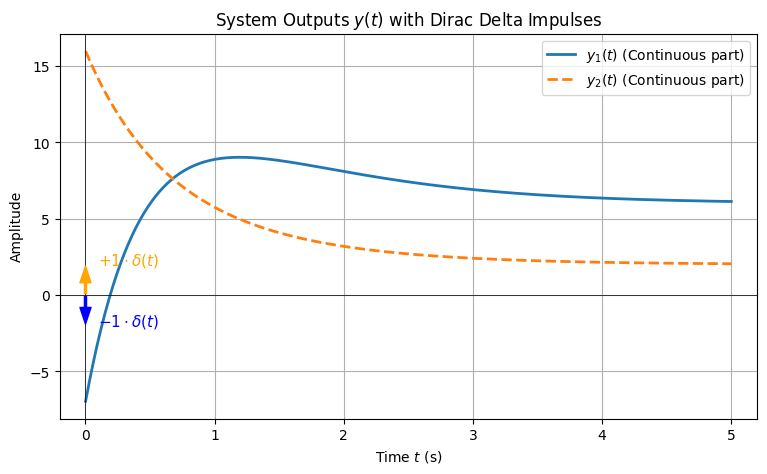

In [5]:
# Notebook: MIMO System Output Analysis (Corrected Annotations & Syntax)
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# 1. Setup Symbols and Matrices
s = sp.symbols('s')
t_sym = sp.symbols('t', real=True, positive=True)

# 2. Compute Resolvent, Output Y(s), and Transfer Function Matrix H(s)
A = sp.Matrix([[-1, 1], [0, -2]])
B = sp.Matrix([[1, 1], [0, 1]])
C = sp.Matrix([[5, -6], [2, 4]])
D = sp.Matrix([[1, -1], [0, 1]])
q0 = sp.Matrix([1, 2])
X_s = sp.Matrix([1 / s, 1])

Phi = (s * sp.eye(2) - A).inv()
Y_s = C * Phi * q0 + (C * Phi * B + D) * X_s

# 3. Numerical Evaluation for Continuous Plotting
# (Τα συνεχή τμήματα των εξισώσεων)
y1_cont_expr = 6 + 20 * sp.exp(-t_sym) - 33 * sp.exp(-2 * t_sym)
y2_cont_expr = 2 + 8 * sp.exp(-t_sym) + 6 * sp.exp(-2 * t_sym)

f_y1 = sp.lambdify(t_sym, y1_cont_expr, 'numpy')
f_y2 = sp.lambdify(t_sym, y2_cont_expr, 'numpy')

t_vals = np.linspace(0.001, 5, 500)
y1_vals = f_y1(t_vals)
y2_vals = f_y2(t_vals)

# 4. Plotting with Raw Strings (r'') to avoid SyntaxWarning
plt.figure(figsize=(9, 5))

plt.plot(t_vals, y1_vals, label=r'$y_1(t)$ (Continuous part)', linewidth=2)
plt.plot(t_vals, y2_vals, label=r'$y_2(t)$ (Continuous part)', linewidth=2, linestyle='--')

# Annotations (Raw strings used here)
# -1*delta(t) points downwards
plt.annotate('', xy=(0, -2), xytext=(0, 0),
             arrowprops=dict(facecolor='blue', edgecolor='blue', shrink=0.05, width=1.5, headwidth=8))
plt.text(0.1, -2, r'$-1 \cdot \delta(t)$', color='blue', fontsize=11, fontweight='bold')

# +1*delta(t) points upwards
plt.annotate('', xy=(0, 2), xytext=(0, 0),
             arrowprops=dict(facecolor='orange', edgecolor='orange', shrink=0.05, width=1.5, headwidth=8))
plt.text(0.1, 2, r'$+1 \cdot \delta(t)$', color='orange', fontsize=11, fontweight='bold')

plt.title(r'System Outputs $y(t)$ with Dirac Delta Impulses')
plt.xlabel('Time $t$ (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend(loc='upper right')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-0.2, 5.2)
plt.show()